# FineBio Problem Solver (Initial Steps)

This notebook is the **foundation** for building next-step prediction + newbie guidance.

We start by fixing/quantifying the dataset issues that will also appear in the real environment:

- **Temporal alignment noise** between video frames and labels
- **Missing/partial labels** (verb/manipulated/affected often blank)
- **Class imbalance** (some steps dominate)
- **Multi-view sync + occlusion** (FPV/TPV have different visibility)
- **Evaluation ambiguity** (multiple valid atomic-op orders)

## Deliverables
- A reproducible **index** of all FineBio instances and files on disk
- Diagnostics + plots for label coverage/imbalance
- Utilities to produce **frame-level** and **window-level** targets with smoothing
- A clean **train/val/test split** and evaluation harness


In [4]:
# Imports + paths
from __future__ import annotations

import os
import json
import zipfile
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, List, Optional, Tuple
from collections import Counter, defaultdict

import numpy as np
import pandas as pd

import cv2

import matplotlib.pyplot as plt

# --- Configure these ---
DATASET_PATH = Path("/home/nyan/FineBio")
KPROJECT_PATH = Path("/home/nyan/k-project")

ANNOTATIONS_DIR = DATASET_PATH / "01 annotations"
ACTION_DIR = ANNOTATIONS_DIR / "finebio_action_annotations"  # extracted folder
ACTION_ZIP = ANNOTATIONS_DIR / "finebio_action_annotations.zip"

COCO_DIR = ANNOTATIONS_DIR / "finebio_coco_annotations"      # extracted folder
COCO_ZIP = ANNOTATIONS_DIR / "finebio_coco_annotations.zip"

print("DATASET_PATH:", DATASET_PATH)
print("ACTION_DIR exists:", ACTION_DIR.exists())
print("COCO_DIR exists:", COCO_DIR.exists())

# Auto-extract if needed
if not ACTION_DIR.exists() and ACTION_ZIP.exists():
    with zipfile.ZipFile(ACTION_ZIP, "r") as zf:
        zf.extractall(ANNOTATIONS_DIR)
    print("Extracted action annotations")

if not COCO_DIR.exists() and COCO_ZIP.exists():
    with zipfile.ZipFile(COCO_ZIP, "r") as zf:
        zf.extractall(ANNOTATIONS_DIR)
    print("Extracted COCO annotations")

print("Ready.")

DATASET_PATH: /home/nyan/FineBio
ACTION_DIR exists: True
COCO_DIR exists: True
Ready.


## 1) Build a unified instance index

We build an index table keyed by `instance_id` (e.g. `P03_02_01`) with:
- paths to FPV video(s)
- paths to TPV video(s) (T1..T5)
- whether action labels exist
- whether instance appears in mistake trials

This index becomes the single source of truth for training/eval.

In [5]:
def resolve_video_paths(instance_id: str, view: str) -> List[Path]:
    """Return all matching video paths for a given instance id and view.

    Note: FineBio has multiple directories per split.
    """
    paths: List[Path] = []

    if view == "tpv":
        tpv_dirs = [
            DATASET_PATH / "05 finebio_videos_tpv_train" / "finebio_videos",
            DATASET_PATH / "06 finebio_videos_tpv_valid" / "finebio_videos",
            DATASET_PATH / "08 finebio_videos_tpv_test" / "finebio_videos",
        ]
        trials = ["T1", "T2", "T3", "T4", "T5"]
        for d in tpv_dirs:
            for t in trials:
                cand = d / f"{instance_id}_{t}.mp4"
                if cand.exists():
                    paths.append(cand)

    elif view == "fpv":
        fpv_dirs = [
            DATASET_PATH / "09 finebio_videos_fpv_train" / "finebio_videos",
            DATASET_PATH / "11 finebio_videos_fpv_valid" / "finebio_videos",
            DATASET_PATH / "04 finebio_videos_fpv_test",
        ]
        trials = ["T1", "T2", "T3", "T4", "T5"]
        for d in fpv_dirs:
            cand_single = d / f"{instance_id}.mp4"
            if cand_single.exists():
                paths.append(cand_single)
            for t in trials:
                cand = d / f"{instance_id}_{t}.mp4"
                if cand.exists():
                    paths.append(cand)
    else:
        raise ValueError(f"Unknown view: {view}")

    # De-dupe while preserving order
    seen = set()
    out = []
    for p in paths:
        if str(p) not in seen:
            out.append(p)
            seen.add(str(p))
    return out


def build_instance_index(limit: Optional[int] = None) -> pd.DataFrame:
    action_files = sorted(ACTION_DIR.glob("P*.txt")) if ACTION_DIR.exists() else []
    instance_ids = [p.stem for p in action_files]
    if limit is not None:
        instance_ids = instance_ids[:limit]

    mistake_dir = DATASET_PATH / "07 finebio_mistake_trials" / "finebio_mistake_trials"
    mistake_videos = list(mistake_dir.glob("*.mp4")) if mistake_dir.exists() else []
    mistake_ids = set([v.stem.split("_")[0] + "_" + v.stem.split("_")[1] + "_" + v.stem.split("_")[2] for v in mistake_videos if len(v.stem.split("_")) >= 3])

    rows = []
    for iid in instance_ids:
        fpv = resolve_video_paths(iid, "fpv")
        tpv = resolve_video_paths(iid, "tpv")
        rows.append({
            "instance_id": iid,
            "has_action_labels": (ACTION_DIR / f"{iid}.txt").exists(),
            "fpv_count": len(fpv),
            "tpv_count": len(tpv),
            "fpv_paths": [str(p) for p in fpv],
            "tpv_paths": [str(p) for p in tpv],
            "is_mistake_trial": iid in mistake_ids,
        })

    df = pd.DataFrame(rows)
    return df


idx = build_instance_index()
print("Indexed instances:", len(idx))
print(idx.head(3))
print("\nCoverage:")
print(idx[["has_action_labels","fpv_count","tpv_count","is_mistake_trial"]].describe(include='all'))

Indexed instances: 226
  instance_id  has_action_labels  fpv_count  tpv_count  \
0   P01_01_01               True          1          5   
1   P01_01_02               True          1          5   
2   P01_02_01               True          1          5   

                                           fpv_paths  \
0  [/home/nyan/FineBio/09 finebio_videos_fpv_trai...   
1  [/home/nyan/FineBio/09 finebio_videos_fpv_trai...   
2  [/home/nyan/FineBio/09 finebio_videos_fpv_trai...   

                                           tpv_paths  is_mistake_trial  
0  [/home/nyan/FineBio/05 finebio_videos_tpv_trai...             False  
1  [/home/nyan/FineBio/05 finebio_videos_tpv_trai...             False  
2  [/home/nyan/FineBio/05 finebio_videos_tpv_trai...             False  

Coverage:
       has_action_labels   fpv_count   tpv_count is_mistake_trial
count                226  226.000000  226.000000              226
unique                 1         NaN         NaN                1
top               

## 2) Action-label diagnostics (what’s missing / noisy?)

We parse each `P*.txt` action file and measure:
- missing rates: `verb`, `manipulated_object`, `affected_object`
- step/task distribution + imbalance
- interval sanity: overlaps, gaps, negative durations
- typical step duration distributions (helps choose smoothing windows)


Total labeled intervals: 54200
neg_dur          0.000000
missing_verb     0.065332
missing_manip    0.065332
missing_aff      0.568838
missing_task     0.934668
dtype: float64

Unique tasks: 33
task
                          50659
spindown                    529
pipetting                   277
aspirate_supernatant        270
vortex                      268
place_in_magnetic_rack      230
shake_plate                 227
add_wash_buffer             146
aspirate_pbs                136
add_pbs                     136
Name: count, dtype: int64


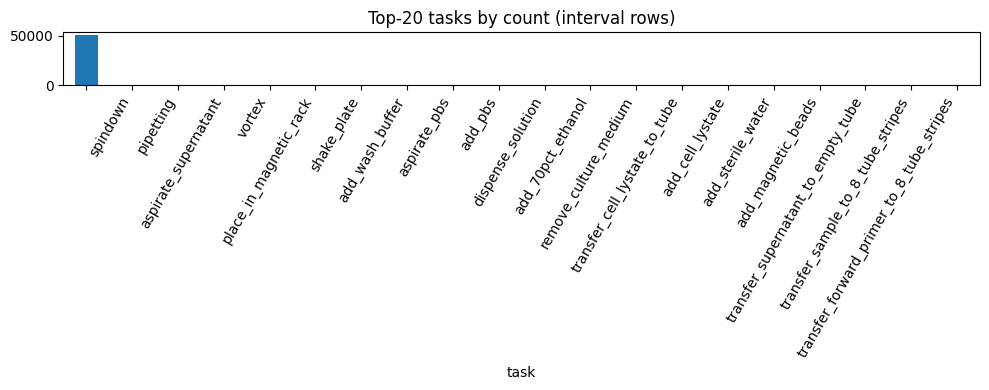

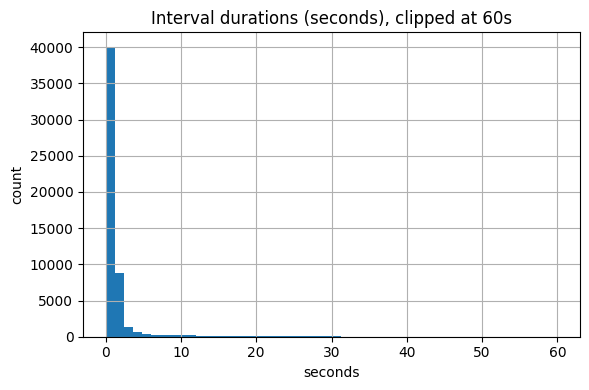

In [6]:
@dataclass
class FineBioAction:
    start_sec: float
    end_sec: float
    task: str
    hand_side: Optional[str]
    verb: Optional[str]
    manipulated_object: Optional[str]
    affected_object: Optional[str]


def load_actions(instance_id: str) -> List[FineBioAction]:
    txt_path = ACTION_DIR / f"{instance_id}.txt"
    out: List[FineBioAction] = []
    if not txt_path.exists():
        return out

    with open(txt_path, "r") as f:
        header = f.readline().strip().split(",")
        # Expect: start_sec,end_sec,task,hand_side,verb,manipulated_object,affected_object
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",")
            while len(parts) < 7:
                parts.append("")
            try:
                start_sec, end_sec = float(parts[0]), float(parts[1])
            except ValueError:
                continue
            task, hand_side, verb, manipulated, affected = parts[2:7]
            out.append(
                FineBioAction(
                    start_sec=start_sec,
                    end_sec=end_sec,
                    task=task or "",
                    hand_side=hand_side or None,
                    verb=verb or None,
                    manipulated_object=manipulated or None,
                    affected_object=affected or None,
                )
            )
    return out


def actions_to_df(actions: List[FineBioAction], instance_id: str) -> pd.DataFrame:
    rows = []
    for a in actions:
        rows.append({
            "instance_id": instance_id,
            "start_sec": a.start_sec,
            "end_sec": a.end_sec,
            "dur": float(a.end_sec - a.start_sec),
            "task": a.task,
            "hand_side": a.hand_side,
            "verb": a.verb,
            "manipulated_object": a.manipulated_object,
            "affected_object": a.affected_object,
        })
    return pd.DataFrame(rows)


def compute_label_diagnostics(idx_df: pd.DataFrame, max_instances: Optional[int] = None) -> pd.DataFrame:
    inst = idx_df["instance_id"].tolist()
    if max_instances is not None:
        inst = inst[:max_instances]

    frames = []
    for iid in inst:
        acts = load_actions(iid)
        if not acts:
            continue
        df = actions_to_df(acts, iid)
        frames.append(df)

    if not frames:
        return pd.DataFrame()

    all_df = pd.concat(frames, ignore_index=True)

    # Sanity flags
    all_df["neg_dur"] = all_df["dur"] < 0
    all_df["missing_task"] = all_df["task"].isna() | (all_df["task"] == "")
    all_df["missing_verb"] = all_df["verb"].isna()
    all_df["missing_manip"] = all_df["manipulated_object"].isna()
    all_df["missing_aff"] = all_df["affected_object"].isna()

    return all_df


all_actions_df = compute_label_diagnostics(idx)
print("Total labeled intervals:", len(all_actions_df))
print(all_actions_df[["missing_task","missing_verb","missing_manip","missing_aff","neg_dur"]].mean().sort_values())

# Task imbalance
task_counts = all_actions_df["task"].value_counts()
print("\nUnique tasks:", len(task_counts))
print(task_counts.head(10))

plt.figure(figsize=(10,4))
task_counts.head(20).plot(kind="bar")
plt.title("Top-20 tasks by count (interval rows)")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

# Duration distribution (only positive)
plt.figure(figsize=(6,4))
all_actions_df.loc[all_actions_df["dur"] > 0, "dur"].clip(upper=60).hist(bins=50)
plt.title("Interval durations (seconds), clipped at 60s")
plt.xlabel("seconds")
plt.ylabel("count")
plt.tight_layout()
plt.show()

## 3) Robust interval→frame/window alignment (core FineBio fix)

FineBio gives **interval labels** (start/end seconds). Real training uses **frame/window labels**.

Problems we solve here:
- boundary jitter (annotation vs video time)
- missing labels (verb/manipulated/affected)
- overlaps/gaps

We produce window targets for:
- **current step** (task)
- **next step** (task at t+Δ)

with optional smoothing near boundaries.

In [7]:
def find_interval_label(t: float, actions: List[FineBioAction]) -> Optional[FineBioAction]:
    # First match (there shouldn't be many overlaps; if there are, we treat as ambiguous)
    for a in actions:
        if a.start_sec <= t <= a.end_sec:
            return a
    return None


def build_time_grid(video_path: Path, fps: float = 1.0, max_t: Optional[float] = None) -> np.ndarray:
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise RuntimeError(f"Cannot open video: {video_path}")
    video_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    dur = n / video_fps if video_fps > 0 else 0.0
    cap.release()
    if max_t is not None:
        dur = min(dur, float(max_t))
    step = 1.0 / fps
    return np.arange(0.0, max(dur - 1e-6, 0.0), step, dtype=np.float32)


def align_instance_labels(instance_id: str,
                          video_path: Path,
                          fps: float = 1.0,
                          next_horizon_sec: float = 5.0,
                          boundary_smooth_sec: float = 1.0) -> pd.DataFrame:
    """Return a time-grid dataframe with current + next step labels.

    boundary_smooth_sec: frames within this distance to a boundary are marked as ambiguous.
    """
    actions = load_actions(instance_id)
    if not actions:
        return pd.DataFrame()

    # Sort intervals just in case
    actions = sorted(actions, key=lambda a: (a.start_sec, a.end_sec))

    ts = build_time_grid(video_path, fps=fps)

    rows = []
    # Precompute boundaries
    boundaries = []
    for a in actions:
        boundaries.append(a.start_sec)
        boundaries.append(a.end_sec)
    boundaries = np.array(sorted(set(boundaries)), dtype=np.float32)

    for t in ts:
        cur = find_interval_label(float(t), actions)
        nxt = find_interval_label(float(t + next_horizon_sec), actions)

        # Ambiguity near boundaries
        near_boundary = False
        if boundaries.size > 0 and boundary_smooth_sec > 0:
            if np.min(np.abs(boundaries - t)) <= boundary_smooth_sec:
                near_boundary = True

        rows.append({
            "instance_id": instance_id,
            "t": float(t),
            "current_task": cur.task if cur else None,
            "next_task": nxt.task if nxt else None,
            "near_boundary": near_boundary,
        })

    df = pd.DataFrame(rows)

    # Mark ambiguous labels near boundary as None (ignore during training)
    df.loc[df["near_boundary"], "current_task"] = None
    df.loc[df["near_boundary"], "next_task"] = None

    return df


# Demo on one instance
_demo = idx.iloc[0]
_demo_id = _demo.instance_id
_demo_fpv = Path(_demo.fpv_paths[0]) if _demo.fpv_count > 0 else None

print("Demo instance:", _demo_id)
print("Demo FPV:", _demo_fpv)

if _demo_fpv is not None:
    aligned = align_instance_labels(_demo_id, _demo_fpv, fps=1.0, next_horizon_sec=5.0, boundary_smooth_sec=1.0)
    print(aligned.head(10))
    print("Labeled current_task coverage:", aligned.current_task.notna().mean())
    print("Labeled next_task coverage:", aligned.next_task.notna().mean())


Demo instance: P01_01_01
Demo FPV: /home/nyan/FineBio/09 finebio_videos_fpv_train/finebio_videos/P01_01_01.mp4
  instance_id    t           current_task              next_task  \
0   P01_01_01  0.0                   None                   None   
1   P01_01_01  1.0                   None                   None   
2   P01_01_01  2.0                   None                   None   
3   P01_01_01  3.0  remove_culture_medium  remove_culture_medium   
4   P01_01_01  4.0  remove_culture_medium  remove_culture_medium   
5   P01_01_01  5.0                   None                   None   
6   P01_01_01  6.0                   None                   None   
7   P01_01_01  7.0                   None                   None   
8   P01_01_01  8.0                   None                   None   
9   P01_01_01  9.0                   None                   None   

   near_boundary  
0           True  
1           True  
2           True  
3          False  
4          False  
5           True  
6      

## 4) Fix: Separate STEP intervals vs ATOMIC-OP intervals

Important FineBio detail:
- Rows with **`task` filled** are **step-level** intervals.
- Rows with **`verb` filled** (and `task` often empty) are **atomic-operation** intervals.

So for **step segmentation / next-step prediction**, we must align against **step-level intervals only**.


In [8]:
def split_step_and_atomic(actions: List[FineBioAction]) -> Tuple[List[FineBioAction], List[FineBioAction]]:
    """Return (step_intervals, atomic_intervals)."""
    step_intervals = [a for a in actions if a.task is not None and a.task != ""]
    atomic_intervals = [a for a in actions if (a.verb is not None and a.verb != "")]
    # Sort
    step_intervals = sorted(step_intervals, key=lambda a: (a.start_sec, a.end_sec))
    atomic_intervals = sorted(atomic_intervals, key=lambda a: (a.start_sec, a.end_sec))
    return step_intervals, atomic_intervals


def interval_sanity_simple(actions: List[FineBioAction]) -> Dict[str, int]:
    """Overlap/gap sanity *within a single interval list*."""
    acts = sorted(actions, key=lambda a: (a.start_sec, a.end_sec))
    neg = sum((a.end_sec - a.start_sec) < 0 for a in acts)
    overlaps = 0
    gaps = 0
    for a, b in zip(acts, acts[1:]):
        if b.start_sec < a.end_sec:
            overlaps += 1
        if b.start_sec > a.end_sec:
            gaps += 1
    return {"neg": neg, "overlaps": overlaps, "gaps": gaps, "count": len(acts)}


def align_instance_step_labels(instance_id: str,
                               video_path: Path,
                               fps: float = 1.0,
                               next_horizon_sec: float = 5.0,
                               boundary_smooth_sec: float = 1.0) -> pd.DataFrame:
    """Align step-level `task` intervals to a time grid."""
    actions = load_actions(instance_id)
    if not actions:
        return pd.DataFrame()

    step_intervals, _ = split_step_and_atomic(actions)
    if not step_intervals:
        return pd.DataFrame()

    ts = build_time_grid(video_path, fps=fps)

    boundaries = np.array(sorted({x for a in step_intervals for x in (a.start_sec, a.end_sec)}), dtype=np.float32)

    rows = []
    for t in ts:
        near_boundary = False
        if boundaries.size > 0 and boundary_smooth_sec > 0:
            if np.min(np.abs(boundaries - t)) <= boundary_smooth_sec:
                near_boundary = True

        cur = find_interval_label(float(t), step_intervals)
        nxt = find_interval_label(float(t + next_horizon_sec), step_intervals)

        rows.append({
            "instance_id": instance_id,
            "t": float(t),
            "current_task": None if near_boundary else (cur.task if cur else None),
            "next_task": None if near_boundary else (nxt.task if nxt else None),
            "near_boundary": near_boundary,
        })

    return pd.DataFrame(rows)


# Recompute key diagnostics correctly (step vs atomic)
step_rows = 0
atomic_rows = 0
step_sanity = Counter()
atomic_sanity = Counter()

for iid in idx.instance_id.tolist():
    acts = load_actions(iid)
    steps, atomics = split_step_and_atomic(acts)
    step_rows += len(steps)
    atomic_rows += len(atomics)
    s1 = interval_sanity_simple(steps)
    a1 = interval_sanity_simple(atomics)
    for k,v in s1.items():
        if k != 'count':
            step_sanity[k] += v
    for k,v in a1.items():
        if k != 'count':
            atomic_sanity[k] += v

print("Step-level interval rows:", step_rows)
print("Atomic-op interval rows:", atomic_rows)
print("\nStep interval sanity totals:", dict(step_sanity))
print("Atomic interval sanity totals:", dict(atomic_sanity))

# Alignment yield demo on a few instances
sample = idx[idx.fpv_count > 0].head(10)
for iid in sample.instance_id.tolist():
    fpv = Path(idx.loc[idx.instance_id==iid, 'fpv_paths'].iloc[0][0])
    aligned = align_instance_step_labels(iid, fpv, fps=1.0, next_horizon_sec=5.0, boundary_smooth_sec=1.0)
    if len(aligned)==0:
        print(iid, "no step intervals")
        continue
    cur_cov = aligned.current_task.notna().mean()
    nxt_cov = aligned.next_task.notna().mean()
    print(iid, "frames@1fps=", len(aligned), "current_task_cov=", f"{cur_cov:.3f}", "next_task_cov=", f"{nxt_cov:.3f}")


Step-level interval rows: 3541
Atomic-op interval rows: 50659

Step interval sanity totals: {'neg': 0, 'overlaps': 0, 'gaps': 2329}
Atomic interval sanity totals: {'neg': 0, 'overlaps': 13409, 'gaps': 26685}
P01_01_01 frames@1fps= 145 current_task_cov= 0.772 next_task_cov= 0.697
P01_01_02 frames@1fps= 126 current_task_cov= 0.825 next_task_cov= 0.786
P01_02_01 frames@1fps= 170 current_task_cov= 0.824 next_task_cov= 0.788
P01_02_02 frames@1fps= 141 current_task_cov= 0.809 next_task_cov= 0.780
P01_03_01 frames@1fps= 216 current_task_cov= 0.713 next_task_cov= 0.662
P01_03_02 frames@1fps= 172 current_task_cov= 0.680 next_task_cov= 0.657
P01_04_01 frames@1fps= 246 current_task_cov= 0.707 next_task_cov= 0.679
P01_04_02 frames@1fps= 201 current_task_cov= 0.657 next_task_cov= 0.637
P01_05_01 frames@1fps= 325 current_task_cov= 0.840 next_task_cov= 0.809
P01_05_02 frames@1fps= 243 current_task_cov= 0.877 next_task_cov= 0.835


## 5) Do something now: Next-step predictor + off-track detector (fast baseline)

This is an **immediate working system** (no deep learning) that:
- learns **step-to-step transition probabilities** from expert trajectories
- predicts **top-K next steps** given current step
- flags **unlikely transitions** as *potential mistakes* (off-track)

Why this is useful:
- gives you an end-to-end loop today
- provides a strong sanity baseline to beat later
- directly supports newbie guidance ("you likely should do X next")

In [9]:
from sklearn.model_selection import train_test_split


def compress_step_sequence(step_intervals: List[FineBioAction]) -> List[str]:
    """Convert step intervals into an ordered step sequence (compress consecutive duplicates)."""
    seq = [a.task for a in step_intervals if a.task]
    if not seq:
        return []
    out = [seq[0]]
    for s in seq[1:]:
        if s != out[-1]:
            out.append(s)
    return out


def build_step_sequences(idx_df: pd.DataFrame, use_view: str = "fpv") -> Dict[str, List[str]]:
    """Return dict: instance_id -> compressed step sequence."""
    seqs = {}
    for iid in idx_df.instance_id.tolist():
        acts = load_actions(iid)
        steps, _ = split_step_and_atomic(acts)
        seq = compress_step_sequence(steps)
        if len(seq) >= 2:
            seqs[iid] = seq
    return seqs


seqs = build_step_sequences(idx)
print("Instances with >=2-step sequences:", len(seqs))
print("Example:", next(iter(seqs.items())))

# Train/val split by instance (no leakage)
all_ids = list(seqs.keys())
train_ids, val_ids = train_test_split(all_ids, test_size=0.2, random_state=42)

print("Train instances:", len(train_ids), "Val instances:", len(val_ids))

# Build transition counts
trans_counts = Counter()
state_counts = Counter()
for iid in train_ids:
    s = seqs[iid]
    for a, b in zip(s, s[1:]):
        trans_counts[(a, b)] += 1
        state_counts[a] += 1

all_steps = sorted(set([x for s in seqs.values() for x in s]))
print("Unique steps seen:", len(all_steps))

# Convert to probabilities with add-k smoothing
alpha = 0.5
next_probs: Dict[str, Dict[str, float]] = {}
for a in all_steps:
    denom = state_counts[a] + alpha * len(all_steps)
    next_probs[a] = {}
    for b in all_steps:
        next_probs[a][b] = (trans_counts[(a, b)] + alpha) / denom


def predict_next_steps(current_step: str, k: int = 3) -> List[Tuple[str, float]]:
    if current_step not in next_probs:
        return []
    items = sorted(next_probs[current_step].items(), key=lambda x: x[1], reverse=True)
    return items[:k]


def transition_nll(a: str, b: str) -> float:
    """Negative log-likelihood of a→b transition under the learned model."""
    p = next_probs.get(a, {}).get(b, 1e-9)
    return float(-np.log(max(p, 1e-9)))


# Evaluate top-1/top-3 next-step accuracy on val
correct1 = 0
correct3 = 0
total = 0
nlls = []

for iid in val_ids:
    s = seqs[iid]
    for a, b in zip(s, s[1:]):
        preds = predict_next_steps(a, k=3)
        if not preds:
            continue
        total += 1
        top1 = preds[0][0]
        top3 = [x[0] for x in preds]
        correct1 += int(top1 == b)
        correct3 += int(b in top3)
        nlls.append(transition_nll(a, b))

print("\nBaseline Markov Next-Step Predictor")
print("Transitions evaluated:", total)
print("Top-1 accuracy:", correct1 / total if total else 0.0)
print("Top-3 accuracy:", correct3 / total if total else 0.0)
print("Median NLL:", float(np.median(nlls)) if nlls else None)

# Example guidance
example_step = all_steps[0]
print("\nExample current step:", example_step)
print("Top-3 next:", predict_next_steps(example_step, k=3))

Instances with >=2-step sequences: 226
Example: ('P01_01_01', ['remove_culture_medium', 'add_pbs', 'shake_plate', 'aspirate_pbs', 'add_cell_lystate', 'shake_plate', 'transfer_cell_lystate_to_tube', 'spindown', 'aspirate_supernatant'])
Train instances: 180 Val instances: 46
Unique steps seen: 32

Baseline Markov Next-Step Predictor
Transitions evaluated: 629
Top-1 accuracy: 0.7917329093799682
Top-3 accuracy: 0.9761526232114467
Median NLL: 0.37106368139083207

Example current step: add_70pct_ethanol
Top-3 next: [('pipetting', 0.5796460176991151), ('vortex', 0.28761061946902655), ('add_70pct_ethanol', 0.004424778761061947)]


In [10]:
# Off-track detector: threshold on transition NLL
# Learn threshold from TRAIN transitions (expert-like)
train_nlls = []
for iid in train_ids:
    s = seqs[iid]
    for a, b in zip(s, s[1:]):
        train_nlls.append(transition_nll(a, b))

nll_thresh = float(np.quantile(train_nlls, 0.95)) if train_nlls else 10.0
print("Learned off-track NLL threshold (95th pct):", nll_thresh)


def is_off_track(prev_step: str, current_step: str) -> Tuple[bool, float]:
    """Return (off_track, nll)."""
    nll = transition_nll(prev_step, current_step)
    return (nll > nll_thresh), nll


def guidance(prev_step: str, current_step: str, k: int = 3) -> Dict:
    off, nll = is_off_track(prev_step, current_step)
    suggestion = predict_next_steps(prev_step, k=k)
    return {
        "prev_step": prev_step,
        "current_step": current_step,
        "off_track": off,
        "transition_nll": nll,
        "suggested_next_steps_from_prev": suggestion,
    }

# Demo: take a random validation transition
if val_ids:
    iid = val_ids[0]
    s = seqs[iid]
    if len(s) >= 3:
        prev_step, current_step = s[0], s[1]
        print("\nDemo guidance:")
        print(guidance(prev_step, current_step, k=3))

Learned off-track NLL threshold (95th pct): 1.8256610209037363

Demo guidance:
{'prev_step': 'transfer_sample_to_8_tube_stripes', 'current_step': 'transfer_pcrmix_to_8_tube_stripes', 'off_track': False, 'transition_nll': 0.37106368139083207, 'suggested_next_steps_from_prev': [('transfer_pcrmix_to_8_tube_stripes', 0.69), ('add_70pct_ethanol', 0.01), ('add_binding_buffer', 0.01)]}


## 6) Real model: Causal Transformer next-step policy (step tokens)

This is a **real neural model** trained on FineBio step sequences:
- Input: step token history (+ optional duration features)
- Output: distribution over next step
- Training: next-token prediction (language-model style)
- Inference: top‑K next steps + confidence
- Off-track: low probability of observed transition ⇒ flag

This is a strong starting point because it learns multi-step context, not just a bigram.

In [11]:
import math
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Build vocab from step sequences
all_steps = sorted(set([x for s in seqs.values() for x in s]))
PAD = "<pad>"
BOS = "<bos>"
UNK = "<unk>"

vocab = [PAD, BOS, UNK] + all_steps
step_to_id = {s:i for i,s in enumerate(vocab)}
id_to_step = {i:s for s,i in step_to_id.items()}

pad_id = step_to_id[PAD]
bos_id = step_to_id[BOS]
unk_id = step_to_id[UNK]

print("Vocab size:", len(vocab))
print("Example mapping:", list(step_to_id.items())[:8])


def encode_seq(seq: List[str]) -> List[int]:
    return [step_to_id.get(s, unk_id) for s in seq]


class StepNextTokenDataset(Dataset):
    """Creates (x, y) pairs for next-token prediction.

    For a sequence [s1, s2, s3], we train on:
      x = [BOS, s1, s2]
      y = [s1, s2, s3]
    """
    def __init__(self, seqs: Dict[str, List[str]], instance_ids: List[str], max_len: int = 64):
        self.samples = []
        self.max_len = max_len
        for iid in instance_ids:
            seq = seqs[iid]
            tok = [bos_id] + encode_seq(seq)
            # shift
            x = tok[:-1]
            y = tok[1:]
            # truncate long
            if len(x) > max_len:
                x = x[-max_len:]
                y = y[-max_len:]
            self.samples.append((torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


def collate_pad(batch):
    xs, ys = zip(*batch)
    T = max(x.shape[0] for x in xs)
    X = torch.full((len(xs), T), pad_id, dtype=torch.long)
    Y = torch.full((len(xs), T), pad_id, dtype=torch.long)
    for i,(x,y) in enumerate(zip(xs,ys)):
        X[i,:x.shape[0]] = x
        Y[i,:y.shape[0]] = y
    # mask pads out of loss
    mask = (Y != pad_id)
    return X, Y, mask


class CausalTransformerLM(nn.Module):
    def __init__(self, vocab_size: int, d_model: int = 256, nhead: int = 8, num_layers: int = 4, dropout: float = 0.1, max_len: int = 256):
        super().__init__()
        self.tok_emb = nn.Embedding(vocab_size, d_model)
        self.pos_emb = nn.Embedding(max_len, d_model)

        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_model*4,
                                               dropout=dropout, batch_first=True)
        self.tr = nn.TransformerEncoder(enc_layer, num_layers=num_layers)
        self.ln = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, vocab_size)
        self.max_len = max_len

    def forward(self, x_tok: torch.Tensor):
        # x_tok: (B,T)
        B,T = x_tok.shape
        if T > self.max_len:
            x_tok = x_tok[:, -self.max_len:]
            T = x_tok.shape[1]
        pos = torch.arange(T, device=x_tok.device).unsqueeze(0).expand(B, T)
        h = self.tok_emb(x_tok) + self.pos_emb(pos)

        # causal mask: prevent attending to future
        # PyTorch expects (T,T) with True = masked
        causal = torch.triu(torch.ones(T, T, device=x_tok.device, dtype=torch.bool), diagonal=1)
        h = self.tr(h, mask=causal)
        h = self.ln(h)
        logits = self.head(h)  # (B,T,V)
        return logits


def topk_next(model: nn.Module, history_steps: List[str], k: int = 3, device: str = "cpu"):
    model.eval()
    tok = [bos_id] + encode_seq(history_steps)
    x = torch.tensor(tok, dtype=torch.long).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = model(x)
        last = logits[0, -1]  # (V,)
        probs = torch.softmax(last, dim=-1)
        vals, idxs = torch.topk(probs, k)
    out = []
    for p,i in zip(vals.tolist(), idxs.tolist()):
        out.append((id_to_step[i], float(p)))
    return out


device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

train_ds = StepNextTokenDataset(seqs, train_ids, max_len=64)
val_ds = StepNextTokenDataset(seqs, val_ids, max_len=64)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, collate_fn=collate_pad)
val_loader = DataLoader(val_ds, batch_size=64, shuffle=False, collate_fn=collate_pad)

model = CausalTransformerLM(vocab_size=len(vocab), d_model=256, nhead=8, num_layers=4, dropout=0.1, max_len=128).to(device)
opt = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

print("Params:", sum(p.numel() for p in model.parameters())/1e6, "M")


Vocab size: 35
Example mapping: [('<pad>', 0), ('<bos>', 1), ('<unk>', 2), ('add_70pct_ethanol', 3), ('add_binding_buffer', 4), ('add_cell_lystate', 5), ('add_extract', 6), ('add_magnetic_beads', 7)]
Device: cuda
Params: 3.210275 M


In [13]:
def eval_next_token(model: nn.Module, loader: DataLoader, device: str) -> Dict[str, float]:
    model.eval()
    total = 0
    correct1 = 0
    correct3 = 0
    losses = []

    ce = nn.CrossEntropyLoss(ignore_index=pad_id)

    with torch.no_grad():
        for X, Y, mask in loader:
            X = X.to(device)
            Y = Y.to(device)
            logits = model(X)  # (B,T,V)
            B,T,V = logits.shape

            loss = ce(logits.view(B*T, V), Y.view(B*T))
            losses.append(loss.item())

            # compute topk on masked positions
            probs = torch.softmax(logits, dim=-1)
            top1 = probs.argmax(dim=-1)
            top3 = probs.topk(3, dim=-1).indices

            m = (Y != pad_id)
            total += int(m.sum().item())
            correct1 += int(((top1 == Y) & m).sum().item())
            correct3 += int((((top3 == Y.unsqueeze(-1)).any(dim=-1)) & m).sum().item())

    return {
        "loss": float(np.mean(losses)) if losses else 0.0,
        "top1": correct1 / total if total else 0.0,
        "top3": correct3 / total if total else 0.0,
        "tokens": total,
    }


# Train (quick)
num_epochs = 15
ce = nn.CrossEntropyLoss(ignore_index=pad_id)

for epoch in range(1, num_epochs + 1):
    model.train()
    tr_losses = []
    for X, Y, mask in train_loader:
        X = X.to(device)
        Y = Y.to(device)
        logits = model(X)
        B,T,V = logits.shape
        loss = ce(logits.view(B*T, V), Y.view(B*T))
        opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        tr_losses.append(loss.item())

    val_metrics = eval_next_token(model, val_loader, device)
    print(f"Epoch {epoch:02d} | train_loss={np.mean(tr_losses):.4f} | val_loss={val_metrics['loss']:.4f} | val_top1={val_metrics['top1']:.3f} | val_top3={val_metrics['top3']:.3f}")


# Example: top‑5 next steps given history
some_iid = val_ids[0]
hist = seqs[some_iid][:5]
print("\nHistory:", hist)
print("Top‑5 next:", topk_next(model, hist, k=5, device=device))


Epoch 01 | train_loss=0.1372 | val_loss=0.1933 | val_top1=0.916 | val_top3=0.979
Epoch 02 | train_loss=0.1373 | val_loss=0.1905 | val_top1=0.916 | val_top3=0.979
Epoch 03 | train_loss=0.1391 | val_loss=0.1984 | val_top1=0.913 | val_top3=0.982
Epoch 04 | train_loss=0.1376 | val_loss=0.1877 | val_top1=0.927 | val_top3=0.985
Epoch 05 | train_loss=0.1403 | val_loss=0.1906 | val_top1=0.913 | val_top3=0.988
Epoch 06 | train_loss=0.1343 | val_loss=0.1990 | val_top1=0.913 | val_top3=0.979
Epoch 07 | train_loss=0.1355 | val_loss=0.1899 | val_top1=0.916 | val_top3=0.988
Epoch 08 | train_loss=0.1366 | val_loss=0.1933 | val_top1=0.916 | val_top3=0.988
Epoch 09 | train_loss=0.1350 | val_loss=0.1883 | val_top1=0.927 | val_top3=0.985
Epoch 10 | train_loss=0.1336 | val_loss=0.1902 | val_top1=0.921 | val_top3=0.988
Epoch 11 | train_loss=0.1335 | val_loss=0.1942 | val_top1=0.916 | val_top3=0.979
Epoch 12 | train_loss=0.1330 | val_loss=0.1927 | val_top1=0.916 | val_top3=0.988
Epoch 13 | train_loss=0.1329

In [14]:
# Off-track scoring using the Transformer policy
# Score = -log P(observed_next | history)

def transition_nll_transformer(model: nn.Module, history: List[str], observed_next: str, device: str) -> float:
    tok = [bos_id] + encode_seq(history)
    x = torch.tensor(tok, dtype=torch.long).unsqueeze(0).to(device)
    y_id = step_to_id.get(observed_next, unk_id)
    with torch.no_grad():
        logits = model(x)[0, -1]
        probs = torch.softmax(logits, dim=-1)
        p = float(probs[y_id].item())
    return float(-math.log(max(p, 1e-9)))


# Learn expert threshold from TRAIN transitions
train_nlls = []
for iid in train_ids:
    s = seqs[iid]
    hist = []
    for i in range(len(s) - 1):
        hist = s[: i + 1]  # history up to current
        nxt = s[i + 1]
        train_nlls.append(transition_nll_transformer(model, hist, nxt, device))

thr = float(np.quantile(train_nlls, 0.95))
print("Transformer off-track NLL threshold (95%):", thr)


def guidance_transformer(history: List[str], observed_next: Optional[str] = None, k: int = 3) -> Dict:
    suggestions = topk_next(model, history, k=k, device=device)
    out = {"history": history, "suggestions": suggestions}
    if observed_next is not None:
        nll = transition_nll_transformer(model, history, observed_next, device)
        out.update({
            "observed_next": observed_next,
            "transition_nll": nll,
            "off_track": bool(nll > thr),
        })
    return out

# Demo
hid = val_ids[0]
seq = seqs[hid]
if len(seq) >= 3:
    history = seq[:2]
    observed = seq[2]
    print("\nDemo transformer guidance:")
    print(guidance_transformer(history, observed_next=observed, k=5))


Transformer off-track NLL threshold (95%): 0.5591611674559833

Demo transformer guidance:
{'history': ['transfer_sample_to_8_tube_stripes', 'transfer_pcrmix_to_8_tube_stripes'], 'suggestions': [('transfer_forward_primer_to_8_tube_stripes', 0.9974536299705505), ('close_8_tube_stripes_lid', 0.0001955148036358878), ('transfer_cell_lystate_to_tube', 0.0001835042203310877), ('transfer_template_dna_to_8_tube_stripes', 0.0001418289466528222), ('transfer_water_to_8_tube_stripes', 0.00014168414054438472)], 'observed_next': 'transfer_forward_primer_to_8_tube_stripes', 'transition_nll': 0.002549617543699625, 'off_track': False}


## 7) Solve FineBio core issues: occlusion + rare atomic ops (actual AO model)

### Problem A: Occlusion ⇒ object evidence disappears ⇒ AO label becomes unlearnable
**Fix**: build *occlusion-robust object state* features:
- **multi-view fusion**: FPV + TPV counts
- **temporal memory**: EMA / max-pool over last W seconds (objects persist even if briefly occluded)
- **hand-conditioned gating**: if hands present, keep nearby-object memory longer (simple heuristic)

### Problem B: AO classes are rare / imbalanced
**Fix**: train with:
- **class-balanced sampling** (oversample rare AO classes)
- **class-balanced / focal loss**

### Output
A real model that predicts **atomic operation = (verb, manipulated_object)** from occlusion-robust features.

In [15]:
# Build AO-labeled windows from atomic intervals, then extract occlusion-robust features.
#
# IMPORTANT: this cell can take a long time because it runs YOLO on many frames.
# If it feels stuck, it's usually doing YOLO inference inside `build_ao_dataset`.

from collections import Counter
import time

import ultralytics
from tqdm.auto import tqdm

YOLO_MODEL_PATH = str(Path('/home/nyan/k-project/runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt'))
yolo = ultralytics.YOLO(YOLO_MODEL_PATH)

# Force GPU if available (huge speedup)
try:
    import torch
    _device = 0 if torch.cuda.is_available() else 'cpu'
except Exception:
    _device = 'cpu'

class_names = list(yolo.names.values())
class_to_idx = {name:i for i,name in enumerate(class_names)}
print('Loaded YOLO:', YOLO_MODEL_PATH, 'num_classes=', len(class_names), 'device=', _device)


def yolo_counts_from_frame(frame, conf: float = 0.25) -> Counter:
    # device arg is supported by ultralytics predict
    res = yolo.predict(frame, conf=conf, verbose=False, device=_device)
    c = Counter()
    if not res:
        return c
    r = res[0]
    if r.boxes is None:
        return c
    for b in r.boxes:
        cls_id = int(b.cls.item())
        name = yolo.names.get(cls_id, str(cls_id))
        c[name] += 1
    return c


def fuse_counts(c1: Counter, c2: Counter) -> Counter:
    out = Counter(c1)
    for k,v in c2.items():
        out[k] += v
    return out


def counts_to_vec(counts: Counter) -> np.ndarray:
    v = np.zeros((len(class_names),), dtype=np.float32)
    for k,val in counts.items():
        if k in class_to_idx:
            v[class_to_idx[k]] = float(val)
    return v


def ema_memory(prev: np.ndarray, cur: np.ndarray, alpha: float = 0.7) -> np.ndarray:
    """Occlusion-robust memory. alpha close to 1 = longer memory."""
    return alpha * prev + (1 - alpha) * cur


def max_memory(prev: np.ndarray, cur: np.ndarray, decay: float = 0.98) -> np.ndarray:
    """Alternative memory: keep max but slowly decay."""
    return np.maximum(prev * decay, cur)


def sample_frames(video_path: Path, t0: float, t1: float, fps: float = 1.0) -> List[Tuple[float, np.ndarray]]:
    """Sample frames between [t0,t1] at fps."""
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        return []
    ts = np.arange(t0, max(t1, t0), 1.0/fps, dtype=np.float32)
    out = []
    for t in ts:
        cap.set(cv2.CAP_PROP_POS_MSEC, float(t) * 1000.0)
        ok, frame = cap.read()
        if ok:
            out.append((float(t), frame))
    cap.release()
    return out


def get_primary_fpv_tpv(iid: str) -> Tuple[Optional[Path], Optional[Path]]:
    fpv = resolve_video_paths(iid, 'fpv')
    tpv = resolve_video_paths(iid, 'tpv')
    return (fpv[0] if fpv else None, tpv[0] if tpv else None)


def build_ao_dataset(instance_ids: List[str],
                     fps: float = 1.0,
                     window_sec: float = 4.0,
                     max_windows_per_instance: int = 50,
                     conf: float = 0.25,
                     memory: str = 'ema'):
    """Return X, y where y is AO class = verb+'_'+manipulated_object.

    Occlusion robustness comes from:
    - FPV+TPV fusion
    - temporal memory within a window

    NOTE: Runtime is roughly proportional to:
      len(instance_ids) * max_windows_per_instance * (window_sec*fps) * 2views
    """
    X = []
    y = []
    meta = []

    ao_to_id = {}

    for iid in tqdm(instance_ids, desc='AO dataset (instances)'):
        acts = load_actions(iid)
        _, atomics = split_step_and_atomic(acts)
        atomics = [a for a in atomics if a.verb and a.manipulated_object]
        if not atomics:
            continue

        fpv, tpv = get_primary_fpv_tpv(iid)
        if fpv is None or tpv is None:
            continue

        atomics = atomics[:max_windows_per_instance]

        t_start_inst = time.time()

        for a in atomics:
            t_mid = 0.5 * (a.start_sec + a.end_sec)
            t0 = max(0.0, t_mid - window_sec/2)
            t1 = t_mid + window_sec/2

            fpv_frames = sample_frames(fpv, t0, t1, fps=fps)
            tpv_frames = sample_frames(tpv, t0, t1, fps=fps)
            if not fpv_frames or not tpv_frames:
                continue

            T = min(len(fpv_frames), len(tpv_frames))
            mem = np.zeros((len(class_names),), dtype=np.float32)
            feats = []

            for i in range(T):
                _, f1 = fpv_frames[i]
                _, f2 = tpv_frames[i]

                c1 = yolo_counts_from_frame(f1, conf=conf)
                c2 = yolo_counts_from_frame(f2, conf=conf)
                fused = fuse_counts(c1, c2)
                cur = counts_to_vec(fused)

                if memory == 'ema':
                    mem = ema_memory(mem, cur, alpha=0.7)
                else:
                    mem = max_memory(mem, cur, decay=0.98)

                feats.append(mem.copy())

            feat_win = np.mean(np.stack(feats, axis=0), axis=0)

            ao = f"{a.verb}_{a.manipulated_object}"
            if ao not in ao_to_id:
                ao_to_id[ao] = len(ao_to_id)

            X.append(feat_win.astype(np.float32))
            y.append(ao_to_id[ao])
            meta.append({'instance_id': iid, 't_mid': t_mid, 'ao': ao})

        dt = time.time() - t_start_inst
        # lightweight heartbeat so it never looks frozen
        if dt > 0:
            print(f"[{iid}] windows={len(atomics)} collected_total={len(y)} time={dt:.1f}s")

    return np.stack(X, axis=0) if X else np.zeros((0,len(class_names)), np.float32), np.array(y, np.int64), ao_to_id, meta


# DEFAULTS tuned to be fast on first run
# Increase gradually once it's working.
small_train_ids = train_ids[:5]
X_ao, y_ao, ao_to_id, meta = build_ao_dataset(
    small_train_ids,
    fps=0.5,                 # fewer frames
    window_sec=2.0,          # shorter window
    max_windows_per_instance=5,
    conf=0.25,
    memory='ema'
)
print('AO dataset:', X_ao.shape, y_ao.shape, 'num_AO_classes=', len(ao_to_id))

counts = Counter(y_ao.tolist())
print('Top AO class counts:', counts.most_common(10))


Loaded YOLO: /home/nyan/k-project/runs/detect/runs/finebio_yolo26/yolo26n_joint3/weights/best.pt num_classes= 35 device= 0


AO dataset (instances):   0%|          | 0/5 [00:00<?, ?it/s]

[P08_04_01] windows=5 collected_total=5 time=1.8s
[P06_04_01] windows=5 collected_total=10 time=1.3s
[P17_06_01] windows=5 collected_total=15 time=1.4s
[P18_01_02] windows=5 collected_total=20 time=1.7s
[P29_06_01] windows=5 collected_total=25 time=1.3s
AO dataset: (25, 35) (25,) num_AO_classes= 12
Top AO class counts: [(1, 4), (2, 4), (0, 3), (3, 3), (4, 2), (5, 2), (11, 2), (6, 1), (7, 1), (8, 1)]


In [16]:
# Real AO classifier with class imbalance handling

import torch
import torch.nn.functional as F

class AOClassifier(nn.Module):
    def __init__(self, input_dim: int, num_classes: int, hidden: int = 256, dropout: float = 0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden, num_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_class_weights(y: np.ndarray, num_classes: int) -> torch.Tensor:
    counts = np.bincount(y, minlength=num_classes).astype(np.float32)
    counts[counts == 0] = 1.0
    w = 1.0 / np.sqrt(counts)
    w = w / w.mean()
    return torch.tensor(w, dtype=torch.float32)


# Split train/val on AO windows (quick split)
N = len(y_ao)
perm = np.random.RandomState(42).permutation(N)
split = int(0.8 * N)
tr_idx = perm[:split]
va_idx = perm[split:]

Xtr = torch.tensor(X_ao[tr_idx], dtype=torch.float32)
ytr = torch.tensor(y_ao[tr_idx], dtype=torch.long)
Xva = torch.tensor(X_ao[va_idx], dtype=torch.float32)
yva = torch.tensor(y_ao[va_idx], dtype=torch.long)

num_ao = len(ao_to_id)
model_ao = AOClassifier(input_dim=Xtr.shape[1], num_classes=num_ao, hidden=256).to(device)
opt_ao = torch.optim.AdamW(model_ao.parameters(), lr=3e-4, weight_decay=1e-4)

w = make_class_weights(y_ao, num_ao).to(device)

# Focal loss (helps rare classes)
def focal_loss(logits, target, gamma: float = 2.0, weight: Optional[torch.Tensor] = None):
    logp = F.log_softmax(logits, dim=-1)
    p = torch.exp(logp)
    tgt_logp = logp.gather(1, target.unsqueeze(1)).squeeze(1)
    tgt_p = p.gather(1, target.unsqueeze(1)).squeeze(1)
    loss = -(1 - tgt_p) ** gamma * tgt_logp
    if weight is not None:
        loss = loss * weight[target]
    return loss.mean()


def eval_ao(model, X, y):
    model.eval()
    with torch.no_grad():
        logits = model(X.to(device))
        pred = logits.argmax(dim=-1).cpu()
        acc = float((pred == y.cpu()).float().mean().item())
        top5 = float((logits.topk(5, dim=-1).indices.cpu() == y.cpu().unsqueeze(1)).any(dim=1).float().mean().item())
    return acc, top5

print('Training AO classifier on', len(Xtr), 'windows; val', len(Xva))

for epoch in range(1, 21):
    model_ao.train()
    # minibatch
    bs = 128
    order = np.random.RandomState(epoch).permutation(len(Xtr))
    losses = []
    for i in range(0, len(order), bs):
        j = order[i:i+bs]
        xb = Xtr[j].to(device)
        yb = ytr[j].to(device)
        logits = model_ao(xb)
        loss = focal_loss(logits, yb, gamma=2.0, weight=w)
        opt_ao.zero_grad(); loss.backward(); opt_ao.step()
        losses.append(loss.item())

    acc, top5 = eval_ao(model_ao, Xva, yva)
    print(f'Epoch {epoch:02d} loss={np.mean(losses):.4f} val_acc={acc:.3f} val_top5={top5:.3f}')

# Show a few predictions
id_to_ao = {v:k for k,v in ao_to_id.items()}
model_ao.eval()
with torch.no_grad():
    logits = model_ao(Xva[:10].to(device))
    probs = torch.softmax(logits, dim=-1)
    top = probs.topk(3, dim=-1).indices.cpu().numpy()
for i in range(min(5, len(top))):
    true = id_to_ao[int(yva[i])]
    pred = [id_to_ao[int(t)] for t in top[i]]
    print('true:', true, 'pred_top3:', pred)


Training AO classifier on 20 windows; val 5
Epoch 01 loss=1.7930 val_acc=0.200 val_top5=0.400
Epoch 02 loss=1.7913 val_acc=0.400 val_top5=0.400
Epoch 03 loss=1.7876 val_acc=0.200 val_top5=0.400
Epoch 04 loss=1.7757 val_acc=0.000 val_top5=0.600
Epoch 05 loss=1.7847 val_acc=0.000 val_top5=0.600
Epoch 06 loss=1.7600 val_acc=0.000 val_top5=0.600
Epoch 07 loss=1.7449 val_acc=0.000 val_top5=0.600
Epoch 08 loss=1.7399 val_acc=0.000 val_top5=0.600
Epoch 09 loss=1.7388 val_acc=0.000 val_top5=0.600
Epoch 10 loss=1.7589 val_acc=0.000 val_top5=0.600
Epoch 11 loss=1.7479 val_acc=0.000 val_top5=0.600
Epoch 12 loss=1.7325 val_acc=0.000 val_top5=0.600
Epoch 13 loss=1.7217 val_acc=0.000 val_top5=0.600
Epoch 14 loss=1.7016 val_acc=0.000 val_top5=0.600
Epoch 15 loss=1.7044 val_acc=0.000 val_top5=0.600
Epoch 16 loss=1.6996 val_acc=0.000 val_top5=0.600
Epoch 17 loss=1.6984 val_acc=0.000 val_top5=0.600
Epoch 18 loss=1.6812 val_acc=0.000 val_top5=0.600
Epoch 19 loss=1.6821 val_acc=0.000 val_top5=0.600
Epoch 

## 8) Make AO training real: scale up + cache features + instance-level split

Your run used **25 windows total**, so metrics are noise.

Next steps in code:
1. **Cache AO features** to disk so YOLO inference runs once.
2. Build a larger dataset (e.g., 5k–50k windows depending on time).
3. Split **by instance_id** (no leakage).
4. Report macro metrics (macro‑F1 / per-class recall) to verify rare classes improve.

In [17]:
# Feature caching + scalable dataset build

CACHE_DIR = KPROJECT_PATH / "ao_cache_v1"
CACHE_DIR.mkdir(parents=True, exist_ok=True)


def ao_cache_key(iid: str, t_mid: float, window_sec: float, fps: float, conf: float, memory: str) -> str:
    return f"{iid}__{t_mid:.2f}__w{window_sec:.1f}__fps{fps:.2f}__c{conf:.2f}__{memory}.npz"


def build_ao_dataset_cached(instance_ids: List[str],
                            fps: float = 1.0,
                            window_sec: float = 4.0,
                            max_windows_per_instance: int = 50,
                            conf: float = 0.25,
                            memory: str = 'ema'):
    X = []
    y = []
    meta = []
    ao_to_id = {}

    for iid in tqdm(instance_ids, desc='AO cached (instances)'):
        acts = load_actions(iid)
        _, atomics = split_step_and_atomic(acts)
        atomics = [a for a in atomics if a.verb and a.manipulated_object]
        if not atomics:
            continue

        fpv, tpv = get_primary_fpv_tpv(iid)
        if fpv is None or tpv is None:
            continue

        atomics = atomics[:max_windows_per_instance]

        for a in atomics:
            t_mid = 0.5 * (a.start_sec + a.end_sec)
            ao = f"{a.verb}_{a.manipulated_object}"
            if ao not in ao_to_id:
                ao_to_id[ao] = len(ao_to_id)
            y_id = ao_to_id[ao]

            key = ao_cache_key(iid, t_mid, window_sec, fps, conf, memory)
            fpath = CACHE_DIR / key

            if fpath.exists():
                data = np.load(fpath)
                feat_win = data["x"].astype(np.float32)
            else:
                t0 = max(0.0, t_mid - window_sec/2)
                t1 = t_mid + window_sec/2

                fpv_frames = sample_frames(fpv, t0, t1, fps=fps)
                tpv_frames = sample_frames(tpv, t0, t1, fps=fps)
                if not fpv_frames or not tpv_frames:
                    continue

                T = min(len(fpv_frames), len(tpv_frames))
                mem = np.zeros((len(class_names),), dtype=np.float32)
                feats = []
                for i in range(T):
                    _, f1 = fpv_frames[i]
                    _, f2 = tpv_frames[i]

                    c1 = yolo_counts_from_frame(f1, conf=conf)
                    c2 = yolo_counts_from_frame(f2, conf=conf)
                    fused = fuse_counts(c1, c2)
                    cur = counts_to_vec(fused)

                    if memory == 'ema':
                        mem = ema_memory(mem, cur, alpha=0.7)
                    else:
                        mem = max_memory(mem, cur, decay=0.98)

                    feats.append(mem.copy())

                feat_win = np.mean(np.stack(feats, axis=0), axis=0).astype(np.float32)
                np.savez_compressed(fpath, x=feat_win)

            X.append(feat_win)
            y.append(y_id)
            meta.append({"instance_id": iid, "t_mid": float(t_mid), "ao": ao})

    X = np.stack(X, axis=0) if X else np.zeros((0, len(class_names)), np.float32)
    y = np.array(y, np.int64)
    return X, y, ao_to_id, meta


# Scale knobs (start medium; adjust up/down)
AO_TRAIN_INSTANCES = 60
WINDOWS_PER_INSTANCE = 60
FPS = 1.0
WINDOW_SEC = 4.0

scaled_ids = train_ids[:AO_TRAIN_INSTANCES]
X_ao, y_ao, ao_to_id, meta = build_ao_dataset_cached(
    scaled_ids,
    fps=FPS,
    window_sec=WINDOW_SEC,
    max_windows_per_instance=WINDOWS_PER_INSTANCE,
    conf=0.25,
    memory='ema'
)
print('Scaled AO dataset:', X_ao.shape, y_ao.shape, 'AO classes:', len(ao_to_id))

# Imbalance snapshot
counts = Counter(y_ao.tolist())
print('Most common:', counts.most_common(10))
print('Least common:', sorted(counts.items(), key=lambda x: x[1])[:10])


AO cached (instances):   0%|          | 0/60 [00:00<?, ?it/s]

Scaled AO dataset: (3600, 35) (3600,) AO classes: 70
Most common: [(21, 239), (4, 216), (5, 210), (2, 196), (8, 181), (27, 165), (1, 163), (28, 159), (29, 151), (47, 122)]
Least common: [(42, 1), (43, 1), (55, 1), (56, 1), (60, 1), (61, 1), (62, 1), (63, 1), (64, 1), (65, 1)]


In [18]:
# Proper split by instance_id (no leakage) + better metrics

from sklearn.metrics import f1_score, classification_report

# Build index lists
meta_df = pd.DataFrame(meta)

# Instance-level split
inst_all = meta_df.instance_id.unique().tolist()
tr_inst, va_inst = train_test_split(inst_all, test_size=0.2, random_state=42)

tr_mask = meta_df.instance_id.isin(tr_inst).values
va_mask = meta_df.instance_id.isin(va_inst).values

Xtr = torch.tensor(X_ao[tr_mask], dtype=torch.float32)
ytr = torch.tensor(y_ao[tr_mask], dtype=torch.long)
Xva = torch.tensor(X_ao[va_mask], dtype=torch.float32)
yva = torch.tensor(y_ao[va_mask], dtype=torch.long)

print('Train windows:', len(Xtr), 'Val windows:', len(Xva), 'Train inst:', len(tr_inst), 'Val inst:', len(va_inst))

num_ao = len(ao_to_id)
model_ao = AOClassifier(input_dim=Xtr.shape[1], num_classes=num_ao, hidden=512).to(device)
opt_ao = torch.optim.AdamW(model_ao.parameters(), lr=2e-4, weight_decay=1e-4)

w = make_class_weights(y_ao, num_ao).to(device)

for epoch in range(1, 16):
    model_ao.train()
    bs = 256
    order = np.random.RandomState(epoch).permutation(len(Xtr))
    losses = []
    for i in range(0, len(order), bs):
        j = order[i:i+bs]
        xb = Xtr[j].to(device)
        yb = ytr[j].to(device)
        logits = model_ao(xb)
        loss = focal_loss(logits, yb, gamma=2.0, weight=w)
        opt_ao.zero_grad(); loss.backward(); opt_ao.step()
        losses.append(loss.item())

    # eval
    model_ao.eval()
    with torch.no_grad():
        logits = model_ao(Xva.to(device))
        pred = logits.argmax(dim=-1).cpu().numpy()
        ytrue = yva.cpu().numpy()
        acc = float((pred == ytrue).mean())
        macro_f1 = float(f1_score(ytrue, pred, average='macro'))
        top5 = float((logits.topk(5, dim=-1).indices.cpu().numpy() == ytrue[:,None]).any(axis=1).mean())

    print(f'Epoch {epoch:02d} loss={np.mean(losses):.4f} val_acc={acc:.3f} val_top5={top5:.3f} val_macroF1={macro_f1:.3f}')

# Show per-class report (trim to classes with >=20 samples in val)
val_counts = Counter(ytrue.tolist())
keep = sorted([c for c,n in val_counts.items() if n >= 20])
if keep:
    print('\nClassification report (val classes with >=20 samples):')
    print(classification_report(ytrue, pred, labels=keep))
else:
    print('\nNot enough per-class support yet; increase AO_TRAIN_INSTANCES / WINDOWS_PER_INSTANCE')


Train windows: 2880 Val windows: 720 Train inst: 48 Val inst: 12
Epoch 01 loss=1.2089 val_acc=0.061 val_top5=0.261 val_macroF1=0.005
Epoch 02 loss=1.1548 val_acc=0.056 val_top5=0.293 val_macroF1=0.004
Epoch 03 loss=1.1165 val_acc=0.058 val_top5=0.308 val_macroF1=0.008
Epoch 04 loss=1.0997 val_acc=0.090 val_top5=0.339 val_macroF1=0.010
Epoch 05 loss=1.0764 val_acc=0.081 val_top5=0.339 val_macroF1=0.013
Epoch 06 loss=1.0544 val_acc=0.086 val_top5=0.350 val_macroF1=0.009
Epoch 07 loss=1.0340 val_acc=0.085 val_top5=0.333 val_macroF1=0.010
Epoch 08 loss=1.0232 val_acc=0.082 val_top5=0.333 val_macroF1=0.011
Epoch 09 loss=1.0003 val_acc=0.081 val_top5=0.333 val_macroF1=0.012
Epoch 10 loss=0.9806 val_acc=0.089 val_top5=0.328 val_macroF1=0.016
Epoch 11 loss=0.9546 val_acc=0.087 val_top5=0.335 val_macroF1=0.016
Epoch 12 loss=0.9354 val_acc=0.089 val_top5=0.340 val_macroF1=0.023
Epoch 13 loss=0.9344 val_acc=0.085 val_top5=0.339 val_macroF1=0.018
Epoch 14 loss=0.9188 val_acc=0.083 val_top5=0.338 v

/home/nyan/miniconda3/envs/k-pro/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nyan/miniconda3/envs/k-pro/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/nyan/miniconda3/envs/k-pro/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

## 9) Single-instance multi-view AO segmentation (P03_02_01)

End-to-end for one instance:
- build common time grid across FPV + TPV views
- run YOLO-26 on all views per timestamp (multi-view fusion)
- align atomic-operation intervals to this grid
- train a small temporal model to segment AO labels over time

In [19]:
# 9.1 Common time grid + multi-view YOLO features for one instance

INSTANCE_ID = "P03_02_01"
FPS_AO = 2.0  # AO segmentation time grid

fpv_paths = resolve_video_paths(INSTANCE_ID, "fpv")
tpv_paths = resolve_video_paths(INSTANCE_ID, "tpv")
assert fpv_paths, f"No FPV for {INSTANCE_ID}"
assert tpv_paths, f"No TPV for {INSTANCE_ID}"

fpv_path = fpv_paths[0]

# Build global time grid using shortest duration across views

def video_duration(path: Path) -> float:
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return 0.0
    fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
    n = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    return n / fps if fps > 0 else 0.0


dur_fpv = video_duration(fpv_path)
_durs_tpv = [video_duration(p) for p in tpv_paths]
T_MIN = float(min([dur_fpv] + _durs_tpv))

print("Instance:", INSTANCE_ID)
print("FPV:", fpv_path, "dur=", dur_fpv)
print("TPV count:", len(tpv_paths), "min_dur=", T_MIN)

# Common time stamps
step = 1.0 / FPS_AO
times = np.arange(0.0, max(T_MIN - 1e-6, 0.0), step, dtype=np.float32)
print("AO time steps:", len(times))


def grab_frame_at(path: Path, t: float):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return None
    cap.set(cv2.CAP_PROP_POS_MSEC, float(t) * 1000.0)
    ok, frame = cap.read()
    cap.release()
    return frame if ok else None


def multi_view_features_for_time(t: float, conf: float = 0.25) -> np.ndarray:
    # FPV
    f_fpv = grab_frame_at(fpv_path, t)
    if f_fpv is None:
        return np.zeros((len(class_names),), np.float32)
    c_fpv = yolo_counts_from_frame(f_fpv, conf=conf)

    # TPVs
    fused = Counter(c_fpv)
    for p in tpv_paths:
        f_tpv = grab_frame_at(p, t)
        if f_tpv is None:
            continue
        c_tpv = yolo_counts_from_frame(f_tpv, conf=conf)
        fused = fuse_counts(fused, c_tpv)

    return counts_to_vec(fused)


# Build feature sequence (this will take some time but only for one instance)
feats = []
for t in tqdm(times, desc=f"YOLO multi-view features {INSTANCE_ID}"):
    v = multi_view_features_for_time(float(t), conf=0.25)
    feats.append(v)

X_mv = np.stack(feats, axis=0)  # (T, C)
print("Feature seq shape:", X_mv.shape)

Instance: P03_02_01
FPV: /home/nyan/FineBio/04 finebio_videos_fpv_test/P03_02_01.mp4 dur= 153.92043333333334
TPV count: 5 min_dur= 153.92043333333334
AO time steps: 308


YOLO multi-view features P03_02_01:   0%|          | 0/308 [00:00<?, ?it/s]

Feature seq shape: (308, 35)


In [20]:
# 9.2 Align atomic-operation labels to this grid

actions = load_actions(INSTANCE_ID)
step_intervals, atomic_intervals = split_step_and_atomic(actions)

# keep only AOs with verb+manip
atomic_intervals = [a for a in atomic_intervals if a.verb and a.manipulated_object]
print('Num atomic intervals:', len(atomic_intervals))

# Build label per time step: AO id or background (-1)
ao_to_id = {}
Y_ao = np.full((len(times),), -1, dtype=np.int64)

for a in atomic_intervals:
    ao = f"{a.verb}_{a.manipulated_object}"
    if ao not in ao_to_id:
        ao_to_id[ao] = len(ao_to_id)
    ao_id = ao_to_id[ao]
    # mark all t within [start,end]
    mask = (times >= a.start_sec) & (times <= a.end_sec)
    Y_ao[mask] = ao_id

print('AO classes:', ao_to_id)
print('Label coverage (non-background):', float((Y_ao != -1).mean()))

Num atomic intervals: 157
AO classes: {'take_blue_pipette': 0, 'open_blue_tip_rack': 1, 'insert_blue_pipette': 2, 'take_cell_culture_plate_lid': 3, 'take_cell_culture_plate': 4, 'press_blue_pipette': 5, 'release_blue_pipette': 6, 'detach_blue_pipette': 7, 'put_cell_culture_plate': 8, 'put_cell_culture_plate_lid': 9, 'take_50ml_tube_rack': 10, 'open_50ml_tube': 11, 'put_50ml_tube_rack': 12, 'eject_blue_pipette': 13, 'shake_cell_culture_plate': 14, 'take_micro_tube': 15, 'open_micro_tube': 16, 'close_micro_tube': 17, 'put_micro_tube': 18, 'put_blue_pipette': 19, 'close_centrifuge': 20, 'open_centrifuge': 21, 'close_blue_tip_rack': 22, 'close_50ml_tube': 23}
Label coverage (non-background): 0.8831168831168831


In [21]:
# 9.3 Train a simple temporal AO segmenter (BiGRU) on this instance

import torch
import torch.nn as nn
import torch.nn.functional as F

T, C = X_mv.shape
num_ao = len(ao_to_id)

# Drop frames with no label? We'll keep background as class 0.
BG_ID = num_ao  # background

Y_seq = np.where(Y_ao == -1, BG_ID, Y_ao)
num_classes = num_ao + 1

X_tensor = torch.tensor(X_mv, dtype=torch.float32)
Y_tensor = torch.tensor(Y_seq, dtype=torch.long)

# Train/val split along time (first 70% train, last 30% val)
split_idx = int(0.7 * T)
X_tr, X_va = X_tensor[:split_idx], X_tensor[split_idx:]
Y_tr, Y_va = Y_tensor[:split_idx], Y_tensor[split_idx:]

print('Train frames:', len(X_tr), 'Val frames:', len(X_va))


class AOSegmenterBiGRU(nn.Module):
    def __init__(self, input_dim: int, hidden: int, num_classes: int, num_layers: int = 2):
        super().__init__()
        self.gru = nn.GRU(input_dim, hidden, num_layers=num_layers, batch_first=True, bidirectional=True)
        self.head = nn.Linear(hidden * 2, num_classes)

    def forward(self, x):
        # x: (B,T,C)
        h, _ = self.gru(x)
        logits = self.head(h)  # (B,T,num_classes)
        return logits


device = 'cuda' if torch.cuda.is_available() else 'cpu'
model_seg = AOSegmenterBiGRU(input_dim=C, hidden=128, num_classes=num_classes, num_layers=2).to(device)
opt_seg = torch.optim.AdamW(model_seg.parameters(), lr=1e-3, weight_decay=1e-4)
ce = nn.CrossEntropyLoss()

# Wrap sequences as (B,T,C)
X_tr_b = X_tr.unsqueeze(0).to(device)
Y_tr_b = Y_tr.unsqueeze(0).to(device)
X_va_b = X_va.unsqueeze(0).to(device)
Y_va_b = Y_va.unsqueeze(0).to(device)

for epoch in range(1, 51):
    model_seg.train()
    logits = model_seg(X_tr_b)  # (1,T,C)
    loss = ce(logits.view(-1, num_classes), Y_tr_b.view(-1))
    opt_seg.zero_grad(); loss.backward(); opt_seg.step()

    if epoch % 5 == 0 or epoch == 1:
        model_seg.eval()
        with torch.no_grad():
            logits_va = model_seg(X_va_b)
            pred_va = logits_va.argmax(dim=-1).view(-1).cpu().numpy()
            ytrue_va = Y_va_b.view(-1).cpu().numpy()
            acc = float((pred_va == ytrue_va).mean())
            # AO-only F1 (exclude background)
            from sklearn.metrics import f1_score
            mask = ytrue_va != BG_ID
            if mask.any():
                f1 = float(f1_score(ytrue_va[mask], pred_va[mask], average='macro'))
            else:
                f1 = 0.0
        print(f'Epoch {epoch:02d} loss={loss.item():.4f} val_acc={acc:.3f} val_AO_F1={f1:.3f}')

# Inspect a small slice of predictions
model_seg.eval()
with torch.no_grad():
    logits_all = model_seg(X_tensor.unsqueeze(0).to(device))
    pred_all = logits_all.argmax(dim=-1).view(-1).cpu().numpy()

id_to_ao = {v:k for k,v in ao_to_id.items()}

print('\nSample timeline (t, true_AO, pred_AO):')
for i in range(0, T, max(1,int(T/20))):
    t = times[i]
    yt = Y_seq[i]
    yp = pred_all[i]
    yt_name = 'BG' if yt==BG_ID else id_to_ao[yt]
    yp_name = 'BG' if yp==BG_ID else id_to_ao.get(yp, 'UNK')
    print(f'{t:6.1f}s  true={yt_name:30s} pred={yp_name:30s}')


Train frames: 215 Val frames: 93
Epoch 01 loss=3.2736 val_acc=0.215 val_AO_F1=0.022
Epoch 05 loss=2.6163 val_acc=0.226 val_AO_F1=0.040
Epoch 10 loss=2.4740 val_acc=0.226 val_AO_F1=0.038
Epoch 15 loss=2.3052 val_acc=0.161 val_AO_F1=0.041
Epoch 20 loss=2.1164 val_acc=0.172 val_AO_F1=0.044
Epoch 25 loss=1.9272 val_acc=0.151 val_AO_F1=0.041
Epoch 30 loss=1.7033 val_acc=0.140 val_AO_F1=0.037
Epoch 35 loss=1.4774 val_acc=0.054 val_AO_F1=0.017
Epoch 40 loss=1.2566 val_acc=0.108 val_AO_F1=0.031
Epoch 45 loss=1.0681 val_acc=0.054 val_AO_F1=0.019
Epoch 50 loss=0.8994 val_acc=0.075 val_AO_F1=0.021

Sample timeline (t, true_AO, pred_AO):
   0.0s  true=BG                             pred=BG                            
   7.5s  true=open_blue_tip_rack             pred=open_blue_tip_rack            
  15.0s  true=release_blue_pipette           pred=release_blue_pipette          
  22.5s  true=insert_blue_pipette            pred=insert_blue_pipette           
  30.0s  true=release_blue_pipette        

## 10) Real features: multi-view hand–object interaction (bboxes, confidences, distances)

Counts are too weak. Here we extract per-timestep features that encode **interaction**:
- per class: count, max confidence
- per class: min distance from any hand center → nearest object center (normalized)
- hand centers/confidences (left/right)

These features are still YOLO-based, but they preserve *geometry* needed to distinguish AOs (take vs put, open vs close, insert vs release).

In [22]:
# 10.1 Detection parsing + interaction feature builder

import numpy as np

LEFT_HAND = "left_hand"
RIGHT_HAND = "right_hand"


def yolo_dets_from_frame(frame, conf: float = 0.25):
    """Return list of dets: {class_name, conf, bbox_xyxy, center_xy} for one frame."""
    res = yolo.predict(frame, conf=conf, verbose=False, device=_device)
    if not res:
        return []
    r = res[0]
    if r.boxes is None or len(r.boxes) == 0:
        return []

    dets = []
    boxes = r.boxes
    for i in range(len(boxes)):
        cls_id = int(boxes.cls[i].item())
        name = yolo.names.get(cls_id, str(cls_id))
        score = float(boxes.conf[i].item())
        x1, y1, x2, y2 = boxes.xyxy[i].tolist()
        cx = 0.5 * (x1 + x2)
        cy = 0.5 * (y1 + y2)
        dets.append({
            "class_name": name,
            "conf": score,
            "bbox": [float(x1), float(y1), float(x2), float(y2)],
            "center": [float(cx), float(cy)],
        })
    return dets


def interaction_features_from_dets(dets: list, img_shape: tuple, class_names: list) -> np.ndarray:
    """Build a feature vector from detections (bbox geometry + hand-object distances).

    Features per class (K classes):
      - count
      - max_conf
      - min_hand_dist (normalized by image diagonal; 1.0 if no hand or no object)

    Plus global hand features:
      - left_hand_conf, right_hand_conf
      - left_hand_xy (normalized), right_hand_xy (normalized) with (-1,-1) if missing
    """
    H, W = img_shape[:2]
    diag = float(np.sqrt(H*H + W*W) + 1e-6)

    # collect hands
    hands = []  # list of (center_xy, conf)
    left = None
    right = None
    for d in dets:
        if d["class_name"] == LEFT_HAND:
            if left is None or d["conf"] > left[1]:
                left = (np.array(d["center"], np.float32), d["conf"])
        elif d["class_name"] == RIGHT_HAND:
            if right is None or d["conf"] > right[1]:
                right = (np.array(d["center"], np.float32), d["conf"])

    if left is not None:
        hands.append(left)
    if right is not None:
        hands.append(right)

    # per-class aggregates
    K = len(class_names)
    counts = np.zeros((K,), np.float32)
    max_conf = np.zeros((K,), np.float32)

    # store object centers by class
    centers_by_class = [[] for _ in range(K)]

    name_to_idx = {n:i for i,n in enumerate(class_names)}

    for d in dets:
        n = d["class_name"]
        if n not in name_to_idx:
            continue
        j = name_to_idx[n]
        counts[j] += 1.0
        max_conf[j] = max(max_conf[j], float(d["conf"]))
        # ignore hands for object distance per-class
        if n not in (LEFT_HAND, RIGHT_HAND):
            centers_by_class[j].append(np.array(d["center"], np.float32))

    # min hand distance per class
    min_hand_dist = np.ones((K,), np.float32)  # 1.0 = far/unknown
    if hands:
        hand_pts = [h[0] for h in hands]
        for j in range(K):
            if not centers_by_class[j]:
                continue
            # compute min distance from any hand to any object of this class
            md = 1e9
            for c in centers_by_class[j]:
                for hp in hand_pts:
                    md = min(md, float(np.linalg.norm(c - hp)))
            min_hand_dist[j] = min(1.0, md / diag)

    # global hand features
    def hand_feat(hand):
        if hand is None:
            return (0.0, -1.0, -1.0)
        pt, conf = hand
        return (float(conf), float(pt[0] / W), float(pt[1] / H))

    lconf, lx, ly = hand_feat(left)
    rconf, rx, ry = hand_feat(right)

    # final vector
    feat = np.concatenate([
        counts,
        max_conf,
        min_hand_dist,
        np.array([lconf, lx, ly, rconf, rx, ry], np.float32)
    ])

    return feat


# sanity: feature dim
feat_dim = len(class_names)*3 + 6
print('Interaction feature dim:', feat_dim)


Interaction feature dim: 111


In [23]:
# 10.2 Rebuild the single-instance multi-view feature sequence using interaction features

# Reuse INSTANCE_ID / times / fpv_path / tpv_paths from Section 9


def multi_view_interaction_feature(t: float, conf: float = 0.25) -> np.ndarray:
    # FPV
    f_fpv = grab_frame_at(fpv_path, t)
    if f_fpv is None:
        return np.zeros((feat_dim,), np.float32)
    dets_fpv = yolo_dets_from_frame(f_fpv, conf=conf)
    feat_fpv = interaction_features_from_dets(dets_fpv, f_fpv.shape, class_names)

    # TPVs: average features across views (more stable than sum for distances)
    feats = [feat_fpv]
    for p in tpv_paths:
        f = grab_frame_at(p, t)
        if f is None:
            continue
        dets = yolo_dets_from_frame(f, conf=conf)
        feats.append(interaction_features_from_dets(dets, f.shape, class_names))

    return np.mean(np.stack(feats, axis=0), axis=0).astype(np.float32)


feats_int = []
for t in tqdm(times, desc=f"YOLO multi-view interaction feats {INSTANCE_ID}"):
    feats_int.append(multi_view_interaction_feature(float(t), conf=0.25))

X_mv_int = np.stack(feats_int, axis=0)
print('Interaction feature seq shape:', X_mv_int.shape)


YOLO multi-view interaction feats P03_02_01:   0%|          | 0/308 [00:00<?, ?it/s]

Interaction feature seq shape: (308, 111)


In [24]:
# 10.3 Train the AO segmenter again, but on interaction features

T, C = X_mv_int.shape
num_ao = len(ao_to_id)
BG_ID = num_ao
Y_seq = np.where(Y_ao == -1, BG_ID, Y_ao)
num_classes = num_ao + 1

X_tensor = torch.tensor(X_mv_int, dtype=torch.float32)
Y_tensor = torch.tensor(Y_seq, dtype=torch.long)

split_idx = int(0.7 * T)
X_tr, X_va = X_tensor[:split_idx], X_tensor[split_idx:]
Y_tr, Y_va = Y_tensor[:split_idx], Y_tensor[split_idx:]

print('Train frames:', len(X_tr), 'Val frames:', len(X_va), 'feat_dim:', C)

model_seg2 = AOSegmenterBiGRU(input_dim=C, hidden=192, num_classes=num_classes, num_layers=2).to(device)
opt_seg2 = torch.optim.AdamW(model_seg2.parameters(), lr=1e-3, weight_decay=1e-4)

# Handle imbalance between BG and AO by weighting
counts = np.bincount(Y_tr.numpy(), minlength=num_classes).astype(np.float32)
counts[counts == 0] = 1.0
w = 1.0 / np.sqrt(counts)
w = w / w.mean()
ce_w = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))

X_tr_b = X_tr.unsqueeze(0).to(device)
Y_tr_b = Y_tr.unsqueeze(0).to(device)
X_va_b = X_va.unsqueeze(0).to(device)
Y_va_b = Y_va.unsqueeze(0).to(device)

for epoch in range(1, 51):
    model_seg2.train()
    logits = model_seg2(X_tr_b)
    loss = ce_w(logits.view(-1, num_classes), Y_tr_b.view(-1))
    opt_seg2.zero_grad(); loss.backward(); opt_seg2.step()

    if epoch % 5 == 0 or epoch == 1:
        model_seg2.eval()
        with torch.no_grad():
            logits_va = model_seg2(X_va_b)
            pred_va = logits_va.argmax(dim=-1).view(-1).cpu().numpy()
            ytrue_va = Y_va_b.view(-1).cpu().numpy()
            acc = float((pred_va == ytrue_va).mean())
            from sklearn.metrics import f1_score
            mask = ytrue_va != BG_ID
            f1 = float(f1_score(ytrue_va[mask], pred_va[mask], average='macro')) if mask.any() else 0.0
        print(f'[INT] Epoch {epoch:02d} loss={loss.item():.4f} val_acc={acc:.3f} val_AO_F1={f1:.3f}')

# Timeline sample
model_seg2.eval()
with torch.no_grad():
    logits_all = model_seg2(X_tensor.unsqueeze(0).to(device))
    pred_all = logits_all.argmax(dim=-1).view(-1).cpu().numpy()

print('\nSample timeline (t, true_AO, pred_AO) [interaction feats]:')
for i in range(0, T, max(1,int(T/20))):
    t = times[i]
    yt = Y_seq[i]
    yp = pred_all[i]
    yt_name = 'BG' if yt==BG_ID else id_to_ao[yt]
    yp_name = 'BG' if yp==BG_ID else id_to_ao.get(yp, 'UNK')
    print(f'{t:6.1f}s  true={yt_name:30s} pred={yp_name:30s}')


Train frames: 215 Val frames: 93 feat_dim: 111
[INT] Epoch 01 loss=3.2436 val_acc=0.215 val_AO_F1=0.022
[INT] Epoch 05 loss=2.8669 val_acc=0.075 val_AO_F1=0.009
[INT] Epoch 10 loss=2.7425 val_acc=0.140 val_AO_F1=0.038
[INT] Epoch 15 loss=2.5176 val_acc=0.097 val_AO_F1=0.023
[INT] Epoch 20 loss=2.3111 val_acc=0.054 val_AO_F1=0.012
[INT] Epoch 25 loss=2.0578 val_acc=0.108 val_AO_F1=0.039
[INT] Epoch 30 loss=1.9090 val_acc=0.172 val_AO_F1=0.047
[INT] Epoch 35 loss=1.7277 val_acc=0.065 val_AO_F1=0.022
[INT] Epoch 40 loss=1.5288 val_acc=0.054 val_AO_F1=0.017
[INT] Epoch 45 loss=1.3324 val_acc=0.086 val_AO_F1=0.021
[INT] Epoch 50 loss=1.1531 val_acc=0.194 val_AO_F1=0.032

Sample timeline (t, true_AO, pred_AO) [interaction feats]:
   0.0s  true=BG                             pred=BG                            
   7.5s  true=open_blue_tip_rack             pred=open_blue_tip_rack            
  15.0s  true=release_blue_pipette           pred=release_blue_pipette          
  22.5s  true=insert_bl

## 11) AO segmentation without YOLO: FineBio I3D features + temporal segmenter

This is the **proper FineBio baseline** (no object detector at all):
- Load provided **I3D (rgb+flow) video features** for an instance from `FineBio/13 features/*.zip`
- Align atomic-operation intervals to feature indices
- Train a temporal model (BiGRU) to segment AO labels

This targets AO segmentation directly and avoids the manipulated/affected-object problem entirely.

In [25]:
# 11.1 Load I3D features from FineBio zip for one instance

import zipfile
import io

I3D_ZIP = Path('/home/nyan/FineBio/13 features/finebio_i3d_features_atomic_operation_detection_fpv.zip')
assert I3D_ZIP.exists(), f"Missing {I3D_ZIP}"

# Inside the zip, paths look like rgbflow_i3d_features/P03_02_01.npy
feat_key = f"rgbflow_i3d_features/{INSTANCE_ID}.npy"

with zipfile.ZipFile(I3D_ZIP, 'r') as zf:
    if feat_key not in zf.namelist():
        # show a hint
        names = [n for n in zf.namelist() if n.endswith('.npy')][:5]
        raise KeyError(f"{feat_key} not found in zip. Example keys: {names}")
    raw = zf.read(feat_key)

arr = np.load(io.BytesIO(raw))
print('Loaded I3D feature array:', arr.shape, arr.dtype)

# Expect shape (T_feat, D) or (D, T_feat); fix to (T_feat, D)
if arr.ndim == 2:
    if arr.shape[0] < arr.shape[1]:
        # ambiguous, but most feature files are (T, D) with T smaller than D
        T_feat, D = arr.shape
        X_i3d = arr.astype(np.float32)
    else:
        # could be (D,T)
        X_i3d = arr.T.astype(np.float32)
else:
    raise ValueError('Unexpected feature array shape')

T_feat, D = X_i3d.shape
print('I3D seq shape (T,D):', X_i3d.shape)


Loaded I3D feature array: (1154, 2048) float32
I3D seq shape (T,D): (1154, 2048)


In [26]:
# 11.2 Align AO intervals to I3D feature indices

# Use FPV duration to map seconds -> feature index
fpv_dur = video_duration(fpv_path)
sec_per_feat = fpv_dur / float(T_feat) if T_feat > 0 else 1.0
print('FPV duration:', fpv_dur, 'T_feat:', T_feat, 'sec_per_feat≈', sec_per_feat)

# Build AO labels on feature timeline
atomic_intervals = [a for a in atomic_intervals if a.verb and a.manipulated_object]

ao_to_id_i3d = {}
Y_feat = np.full((T_feat,), -1, np.int64)

for a in atomic_intervals:
    ao = f"{a.verb}_{a.manipulated_object}"
    if ao not in ao_to_id_i3d:
        ao_to_id_i3d[ao] = len(ao_to_id_i3d)
    ao_id = ao_to_id_i3d[ao]

    i0 = int(np.floor(a.start_sec / sec_per_feat))
    i1 = int(np.ceil(a.end_sec / sec_per_feat))
    i0 = max(0, min(T_feat-1, i0))
    i1 = max(0, min(T_feat, i1))
    Y_feat[i0:i1] = ao_id

BG_ID = len(ao_to_id_i3d)
Y_feat2 = np.where(Y_feat == -1, BG_ID, Y_feat)
num_classes = BG_ID + 1

print('AO classes (I3D):', len(ao_to_id_i3d))
print('Non-BG coverage:', float((Y_feat2 != BG_ID).mean()))


FPV duration: 153.92043333333334 T_feat: 1154 sec_per_feat≈ 0.13337992489890238
AO classes (I3D): 24
Non-BG coverage: 0.9064124783362218


In [27]:
# 11.3 Train a temporal AO segmenter on I3D features (no YOLO)

from sklearn.metrics import f1_score

X = torch.tensor(X_i3d, dtype=torch.float32)
Y = torch.tensor(Y_feat2, dtype=torch.long)

# time split
split = int(0.7 * T_feat)
X_tr, X_va = X[:split], X[split:]
Y_tr, Y_va = Y[:split], Y[split:]

print('I3D Train steps:', len(X_tr), 'Val steps:', len(X_va), 'D=', X.shape[1])

class I3DSegmenterBiGRU(nn.Module):
    def __init__(self, d_in: int, hidden: int, num_classes: int, layers: int = 2):
        super().__init__()
        self.gru = nn.GRU(d_in, hidden, num_layers=layers, batch_first=True, bidirectional=True)
        self.head = nn.Linear(hidden*2, num_classes)

    def forward(self, x):
        h,_ = self.gru(x)
        return self.head(h)

model_i3d = I3DSegmenterBiGRU(d_in=X.shape[1], hidden=256, num_classes=num_classes, layers=2).to(device)
opt = torch.optim.AdamW(model_i3d.parameters(), lr=5e-4, weight_decay=1e-4)

# class weighting to handle BG
counts = np.bincount(Y_tr.numpy(), minlength=num_classes).astype(np.float32)
counts[counts == 0] = 1.0
w = 1.0 / np.sqrt(counts)
w = w / w.mean()
ce = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32).to(device))

X_tr_b = X_tr.unsqueeze(0).to(device)
Y_tr_b = Y_tr.unsqueeze(0).to(device)
X_va_b = X_va.unsqueeze(0).to(device)
Y_va_b = Y_va.unsqueeze(0).to(device)

for epoch in range(1, 51):
    model_i3d.train()
    logits = model_i3d(X_tr_b)
    loss = ce(logits.view(-1, num_classes), Y_tr_b.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()

    if epoch % 5 == 0 or epoch == 1:
        model_i3d.eval()
        with torch.no_grad():
            logits_va = model_i3d(X_va_b)
            pred_va = logits_va.argmax(dim=-1).view(-1).cpu().numpy()
            ytrue_va = Y_va_b.view(-1).cpu().numpy()
            acc = float((pred_va == ytrue_va).mean())
            mask = ytrue_va != BG_ID
            ao_f1 = float(f1_score(ytrue_va[mask], pred_va[mask], average='macro')) if mask.any() else 0.0
        print(f'[I3D] Epoch {epoch:02d} loss={loss.item():.4f} val_acc={acc:.3f} val_AO_F1={ao_f1:.3f}')

# Print a coarse timeline
id_to_ao_i3d = {v:k for k,v in ao_to_id_i3d.items()}
model_i3d.eval()
with torch.no_grad():
    pred_all = model_i3d(X.unsqueeze(0).to(device)).argmax(dim=-1).view(-1).cpu().numpy()

print('\nI3D timeline sample (index, approx_t, true, pred):')
for i in range(0, T_feat, max(1, int(T_feat/20))):
    t = i * sec_per_feat
    yt = int(Y_feat2[i]); yp = int(pred_all[i])
    yt_name = 'BG' if yt==BG_ID else id_to_ao_i3d.get(yt,'UNK')
    yp_name = 'BG' if yp==BG_ID else id_to_ao_i3d.get(yp,'UNK')
    print(f'{i:4d}  {t:6.1f}s  true={yt_name:28s} pred={yp_name:28s}')


I3D Train steps: 807 Val steps: 347 D= 2048
[I3D] Epoch 01 loss=3.2273 val_acc=0.202 val_AO_F1=0.021
[I3D] Epoch 05 loss=2.7563 val_acc=0.262 val_AO_F1=0.058
[I3D] Epoch 10 loss=2.3928 val_acc=0.254 val_AO_F1=0.076
[I3D] Epoch 15 loss=1.8959 val_acc=0.320 val_AO_F1=0.199
[I3D] Epoch 20 loss=1.4064 val_acc=0.331 val_AO_F1=0.177
[I3D] Epoch 25 loss=1.0006 val_acc=0.331 val_AO_F1=0.158
[I3D] Epoch 30 loss=0.7459 val_acc=0.346 val_AO_F1=0.196
[I3D] Epoch 35 loss=0.5597 val_acc=0.369 val_AO_F1=0.223
[I3D] Epoch 40 loss=0.4700 val_acc=0.372 val_AO_F1=0.243
[I3D] Epoch 45 loss=0.3636 val_acc=0.401 val_AO_F1=0.243
[I3D] Epoch 50 loss=0.2914 val_acc=0.401 val_AO_F1=0.255

I3D timeline sample (index, approx_t, true, pred):
   0     0.0s  true=BG                           pred=BG                          
  57     7.6s  true=open_blue_tip_rack           pred=open_blue_tip_rack          
 114    15.2s  true=release_blue_pipette         pred=release_blue_pipette        
 171    22.8s  true=press_bl